<a href="https://colab.research.google.com/github/Khushi310105/Final_Year_Project/blob/main/IddTdc_EEGNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%%capture
!pip install mne
!unzip "/content/drive/MyDrive/Colab Notebooks/EEG dataset of individuals with intellectual and developmental disorder and healthy controls while observing rest and musical stimulus.zip" -d .

In [3]:
IDD_data_path='/content/EEG dataset of individuals with intellectual and developmental disorder and healthy controls while observing rest and musical stimulus/Data/CleanData/CleanData_IDD/Rest'
TDC_data_path='/content/EEG dataset of individuals with intellectual and developmental disorder and healthy controls while observing rest and musical stimulus/Data/CleanData/CleanData_TDC/Rest'
!rm '/content/EEG dataset of individuals with intellectual and developmental disorder and healthy controls while observing rest and musical stimulus/Data/CleanData/CleanData_IDD/Rest/NDS001_Rest_CD(1).mat'

In [4]:
from glob import glob
import scipy.io
import numpy as np
import mne

In [5]:
def convertmat2mne(data):
  ch_names = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
  ch_types = ['eeg'] * 14
  sampling_freq=128
  info = mne.create_info(ch_names, ch_types=ch_types, sfreq=sampling_freq)
  info.set_montage('standard_1020')
  data=mne.io.RawArray(data, info)
  data.set_eeg_reference()
  data.filter(l_freq=1,h_freq=30)
  epochs=mne.make_fixed_length_epochs(data,duration=4,overlap=0)
  return epochs.get_data()


In [6]:
%%capture
idd_subject=[]
for idd in glob(IDD_data_path+'/*.mat'):
  data=scipy.io.loadmat(idd)['clean_data']
  data=convertmat2mne(data)
  idd_subject.append(data)

In [7]:
%%capture
tdc_subject=[]
for tdc in glob(TDC_data_path+'/*.mat'):
  data=scipy.io.loadmat(tdc)['clean_data']
  data=convertmat2mne(data)
  tdc_subject.append(data)

In [8]:
control_epochs_labels=[len(i)*[0] for i in tdc_subject]
patients_epochs_labels=[len(i)*[1] for i in idd_subject]
print(len(control_epochs_labels),len(patients_epochs_labels))

7 7


In [9]:
data_list=tdc_subject+idd_subject
label_list=control_epochs_labels+patients_epochs_labels
groups_list=[[i]*len(j) for i, j in enumerate(data_list)]
print(len(data_list),len(label_list),len(groups_list))

14 14 14


In [10]:
data_array=np.concatenate(data_list)
label_array=np.concatenate(label_list)
group_array=np.concatenate(groups_list)
data_array=np.moveaxis(data_array,1,2)

print(data_array.shape,label_array.shape,group_array.shape)

(420, 512, 14) (420,) (420,)


In [11]:
from sklearn.model_selection import GroupKFold,LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
gkf=GroupKFold()
from sklearn.base import TransformerMixin,BaseEstimator
from sklearn.preprocessing import StandardScaler
#https://stackoverflow.com/questions/50125844/how-to-standard-scale-a-3d-matrix
class StandardScaler3D(BaseEstimator,TransformerMixin):
    #batch, sequence, channels
    def __init__(self):
        self.scaler = StandardScaler()

    def fit(self,X,y=None):
        self.scaler.fit(X.reshape(-1, X.shape[2]))
        return self

    def transform(self,X):
        return self.scaler.transform(X.reshape( -1,X.shape[2])).reshape(X.shape)

In [17]:
accuracy=[]
for train_index, val_index in gkf.split(data_array, label_array, groups=group_array):
    train_features, train_labels = data_array[train_index], label_array[train_index]
    val_features, val_labels = data_array[val_index], label_array[val_index]
    scaler = StandardScaler3D()
    train_features = scaler.fit_transform(train_features)

    val_features = scaler.transform(val_features)

    train_features = np.transpose(train_features, (0, 2, 1))
    val_features = np.transpose(val_features, (0, 2, 1))

    train_features = train_features[..., np.newaxis]
    val_features = val_features[..., np.newaxis]

    print(train_features.shape, val_features.shape)

    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import Input
    from tensorflow.keras.layers import Conv2D
    from tensorflow.keras.layers import DepthwiseConv2D
    from tensorflow.keras.layers import SeparableConv2D
    from tensorflow.keras.layers import AveragePooling2D
    from tensorflow.keras.layers import BatchNormalization
    from tensorflow.keras.layers import SpatialDropout2D
    from tensorflow.keras.layers import Flatten
    from tensorflow.keras.layers import Dense
    from tensorflow.keras.layers import Activation
    from tensorflow.keras.callbacks import EarlyStopping

    input1 = Input(shape=(14, 512, 1))
    x = Conv2D(
        filters=16,
        kernel_size=(1,32),
        padding='same',
        use_bias=False
    )(input1)

    x = BatchNormalization()(x)

    x = DepthwiseConv2D(
        kernel_size=(14,1),
        use_bias=False,
        depth_multiplier=2
    )(x)

    x = BatchNormalization()(x)

    x = Activation('elu')(x)

    x = AveragePooling2D((1,4))(x)

    x = SpatialDropout2D(0.25)(x)

    x = SeparableConv2D(
        filters=16,
        kernel_size=(1,16),
        padding='same',
        use_bias=False
    )(x)

    x = BatchNormalization()(x)

    x = Activation('elu')(x)

    x = AveragePooling2D((1,8))(x)

    x = SpatialDropout2D(0.25)(x)
    x = Flatten()(x)

    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=input1, outputs=output)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        train_features,
        train_labels,
        epochs=20,
        batch_size=32,
        validation_data=(val_features, val_labels),
        callbacks=[early_stop]
    )
    loss, acc = model.evaluate(
        val_features,
        val_labels
    )

    accuracy.append(acc)

    print("Validation Loss:", loss)

    print("Validation Accuracy:", acc)

print("Average Accuracy:", np.mean(accuracy))

(330, 14, 512, 1) (90, 14, 512, 1)
Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 722ms/step - accuracy: 0.6000 - loss: 0.6736 - val_accuracy: 0.3333 - val_loss: 0.7007
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7030 - loss: 0.6015 - val_accuracy: 0.3333 - val_loss: 0.7112
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7939 - loss: 0.5338 - val_accuracy: 0.3333 - val_loss: 0.7273
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8455 - loss: 0.4247 - val_accuracy: 0.3333 - val_loss: 0.7531
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3333 - loss: 0.7007
Validation Loss: 0.7007150650024414
Validation Accuracy: 0.3333333432674408
(330, 14, 512, 1) (90, 14, 512, 1)
Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 466ms/step - accuracy: 0.4879 - loss: 0.7335 - val_accuracy: 0.3444 - val_loss: 0.6979
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6333 - loss: 0.6391 - val_accuracy: 0.3333 - val_loss: 0.7035
Epoch 3/20
11/11

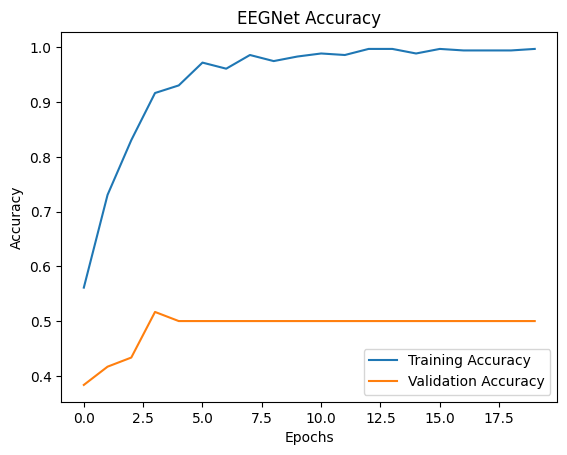

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.title('EEGNet Accuracy')

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

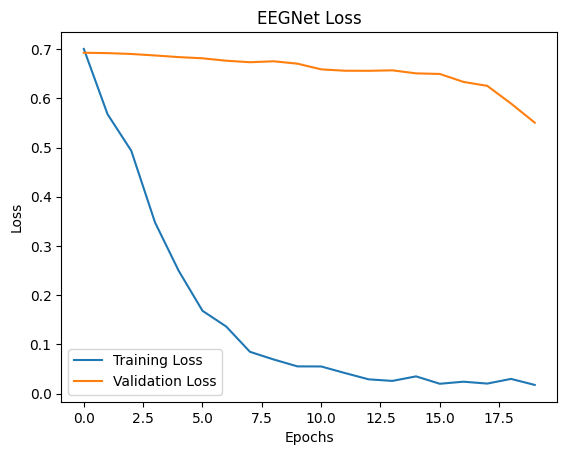

In [19]:
plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title('EEGNet Loss')

plt.xlabel('Epochs')

plt.ylabel('Loss')

plt.legend()

plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 761ms/step


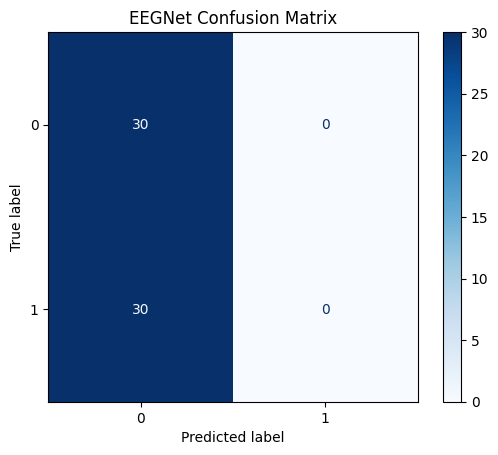

In [20]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

val_predictions = model.predict(val_features)

val_predicted_labels = (
    val_predictions > 0.5
).astype(int)

cm = confusion_matrix(
    val_labels,
    val_predicted_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap='Blues')

plt.title("EEGNet Confusion Matrix")

plt.show()

In [21]:
from sklearn.metrics import classification_report

print(classification_report(
    val_labels,
    val_predicted_labels
))

              precision    recall  f1-score   support

           0       0.50      1.00      0.67        30
           1       0.00      0.00      0.00        30

    accuracy                           0.50        60
   macro avg       0.25      0.50      0.33        60
weighted avg       0.25      0.50      0.33        60



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
